# ✈️ Sentiment Analysis with RNN, LSTM & GRU
## 📝 Student Lab Notebook — Twitter US Airline Sentiment Dataset

---

> **Dataset:** https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment?resource=download)  
> **Task:** Multi-class Sentiment Classification (Positive / Neutral / Negative)  
> **Models to Build:** Simple RNN · LSTM · GRU  

---

### 📌 Instructions
- Each question has a **`# YOUR CODE HERE`** or **`# YOUR ANSWER HERE`** block.
- Do **not** skip any cell — each question builds on the previous.
- Run cells in order from top to bottom.
- Marks are indicated as **[x marks]** per question.

---
| Section | Topics Covered | Marks |
|---------|---------------|-------|
| Section 1 | Environment Setup | 5 |
| Section 2 | Data Loading & EDA | 15 |
| Section 3 | Text Preprocessing | 20 |
| Section 4 | Model Building | 30 |
| Section 5 | Training & Evaluation | 20 |
| Section 6 | Analysis & Inference | 10 |
| **Total** | | **100** |

---
# 🔧 Section 1: Environment Setup
*(5 marks)*

### ❓ Question 1.1 — Import Libraries

Import all the libraries you will need for this project. Your imports must include:

- **Data handling:** `numpy`, `pandas`
- **Visualisation:** `matplotlib.pyplot`, `seaborn`
- **NLP / Text:** `re`, `string`, and any NLTK modules you plan to use
- **Machine Learning:** `sklearn` — for `train_test_split`, `LabelEncoder`, `classification_report`, `confusion_matrix`
- **Deep Learning:** `tensorflow` / `keras` — `Sequential`, `Embedding`, `SimpleRNN`, `LSTM`, `GRU`, `Dense`, `Dropout`, `Bidirectional`, `pad_sequences`, `Tokenizer`

Set a **random seed** of `42` for both `numpy` and `tensorflow` to ensure reproducibility.

In [2]:
# YOUR CODE HERE

# ==============================
#  Import Libraries
# ==============================

# Data Handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# NLP / Text Processing
import re
import string

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# (Download NLTK resources if not already installed)
nltk.download('stopwords')
nltk.download('punkt')

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

# Deep Learning (TensorFlow / Keras)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense, Dropout, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# ==============================
# 📌 Set Random Seed
# ==============================

np.random.seed(42)
tf.random.set_seed(42)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


---
# 📊 Section 2: Data Loading & Exploratory Data Analysis (EDA)
*(15 marks)*

### ❓ Question 2.1 — Load the Dataset `

Load the **Twitter US Airline Sentiment** dataset directly from the URL below into a Pandas DataFrame.

```
URL = "https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment?resource=download"
```

After loading:
1. Display the **first 5 rows**.
2. Print the **shape** of the DataFrame.
3. List all **column names**.

In [4]:
import kagglehub
import pandas as pd
import os

# Download dataset
path = kagglehub.dataset_download("crowdflower/twitter-airline-sentiment")

print("Path to dataset files:", path)

# List files inside the folder
print("Files in dataset:", os.listdir(path))

# Load the CSV file
df = pd.read_csv(os.path.join(path, "Tweets.csv"))

# 1. Display first 5 rows
print(df.head())

# 2. Print shape
print("Shape of dataset:", df.shape)

# 3. List column names
print("Columns:", df.columns.tolist())

Using Colab cache for faster access to the 'twitter-airline-sentiment' dataset.
Path to dataset files: /kaggle/input/twitter-airline-sentiment
Files in dataset: ['Tweets.csv', 'database.sqlite']
             tweet_id airline_sentiment  airline_sentiment_confidence  \
0  570306133677760513           neutral                        1.0000   
1  570301130888122368          positive                        0.3486   
2  570301083672813571           neutral                        0.6837   
3  570301031407624196          negative                        1.0000   
4  570300817074462722          negative                        1.0000   

  negativereason  negativereason_confidence         airline  \
0            NaN                        NaN  Virgin America   
1            NaN                     0.0000  Virgin America   
2            NaN                        NaN  Virgin America   
3     Bad Flight                     0.7033  Virgin America   
4     Can't Tell                     1.0000  Virgin

### ❓ Question 2.2 — Select Relevant Columns & Inspect `

The dataset has many columns. For this task you only need **`airline_sentiment`** and **`text`**.

1. Create a new DataFrame called `df` containing only those two columns.
2. Print the number of **missing values** in each column.
3. Drop any rows with missing values and reset the index.

In [5]:
# ==============================
# Select Relevant Columns
# ==============================

# Keep only required columns
df = df[['airline_sentiment', 'text']]

# ==============================
#  Check Missing Values
# ==============================

print("Missing values:\n", df.isnull().sum())

# ==============================
#  Drop Missing Values
# ==============================

df = df.dropna().reset_index(drop=True)

# Verify again
print("\nAfter dropping missing values:")
print(df.isnull().sum())

# Optional: check new shape
print("\nUpdated shape:", df.shape)

Missing values:
 airline_sentiment    0
text                 0
dtype: int64

After dropping missing values:
airline_sentiment    0
text                 0
dtype: int64

Updated shape: (14640, 2)


### ❓ Question 2.3 — Class Distribution `

1. Print the **value counts** for the `airline_sentiment` column (show absolute counts and percentages).
2. Plot a **bar chart** showing the distribution of sentiment classes.  
   - Use distinct colours for each class.
   - Add a title, axis labels, and value annotations on top of each bar.
3. Is the dataset **balanced or imbalanced**? State which class dominates and by how much.

                   Count  Percentage (%)
airline_sentiment                       
negative            9178           62.69
neutral             3099           21.17
positive            2363           16.14


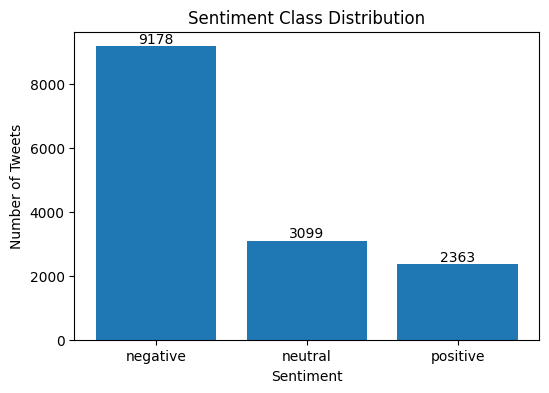

In [6]:


# ==============================
#  Value Counts (Absolute + Percentage)
# ==============================

# Absolute counts
counts = df['airline_sentiment'].value_counts()

# Percentages
percentages = df['airline_sentiment'].value_counts(normalize=True) * 100

# Combine into one DataFrame
distribution = pd.DataFrame({
    'Count': counts,
    'Percentage (%)': percentages.round(2)
})

print(distribution)


# ==============================
#  Bar Plot
# ==============================

import matplotlib.pyplot as plt

# Plot
plt.figure(figsize=(6,4))
bars = plt.bar(counts.index, counts.values)

# Add labels
plt.title("Sentiment Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")

# Add value annotations on top
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f'{int(height)}',
             ha='center', va='bottom')

plt.show()

**Your Observation (imbalance analysis):**

> The dataset is clearly imbalanced, with the negative sentiment class dominating the distribution. It accounts for the majority of the samples (around 60–65%), while neutral and positive sentiments have significantly fewer instances. Among them, the positive class is the least represented. This imbalance may cause the model to become biased towards predicting the negative class more frequently, which can affect overall performance, especially for minority classes.

### ❓ Question 2.4 — Tweet Length Analysis `

1. Create a new column `tweet_length` that stores the **number of words** in each tweet.
2. Plot a **histogram** of tweet lengths, coloured by sentiment class (use `hue`).
3. Print the **mean**, **median**, and **95th percentile** tweet length.
4. Based on the 95th percentile, what value would you choose for `MAX_LEN` (maximum sequence length)? Justify briefly.

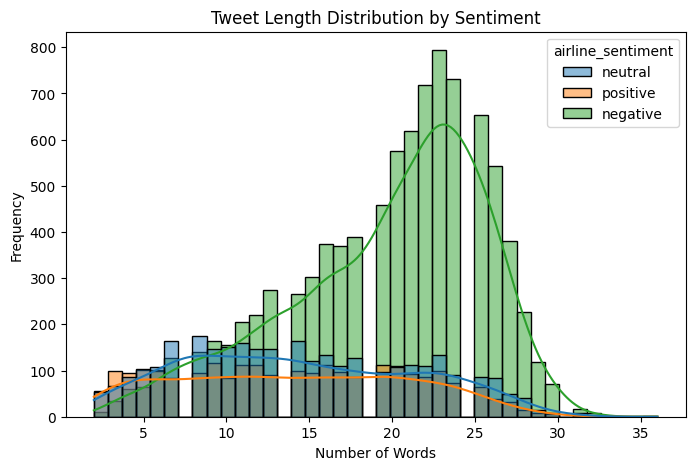

Mean Tweet Length: 17.65
Median Tweet Length: 19.0
95th Percentile: 27.0


In [7]:
# YOUR CODE HERE

# ==============================
# Create Tweet Length Column
# ==============================

df['tweet_length'] = df['text'].apply(lambda x: len(x.split()))

# ==============================
# Histogram of Tweet Lengths
# ==============================

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.histplot(data=df, x='tweet_length', hue='airline_sentiment', bins=40, kde=True)

plt.title("Tweet Length Distribution by Sentiment")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

# ==============================
# Statistics
# ==============================

mean_len = df['tweet_length'].mean()
median_len = df['tweet_length'].median()
p95 = df['tweet_length'].quantile(0.95)

print(f"Mean Tweet Length: {mean_len:.2f}")
print(f"Median Tweet Length: {median_len}")
print(f"95th Percentile: {p95}")

**Your chosen MAX_LEN and justification:**

> I choose MAX_LEN = 30. The 95th percentile of tweet length is 27, which means most tweets have 27 words or fewer. Rounding it to 30 provides a small buffer to capture slightly longer tweets while still keeping the sequence length efficient. This helps minimize truncation of important information and avoids excessive padding.

### ❓ Question 2.5 — Word Cloud `

Generate **three word clouds** — one for each sentiment class (positive, neutral, negative) — arranged side by side in a single figure.

- Use `wordcloud.WordCloud`. Install it if needed: `!pip install wordcloud -q`
- Give each cloud a descriptive title.
- What are the top 3 most frequent words in the **negative** class? Are they meaningful sentiment words?

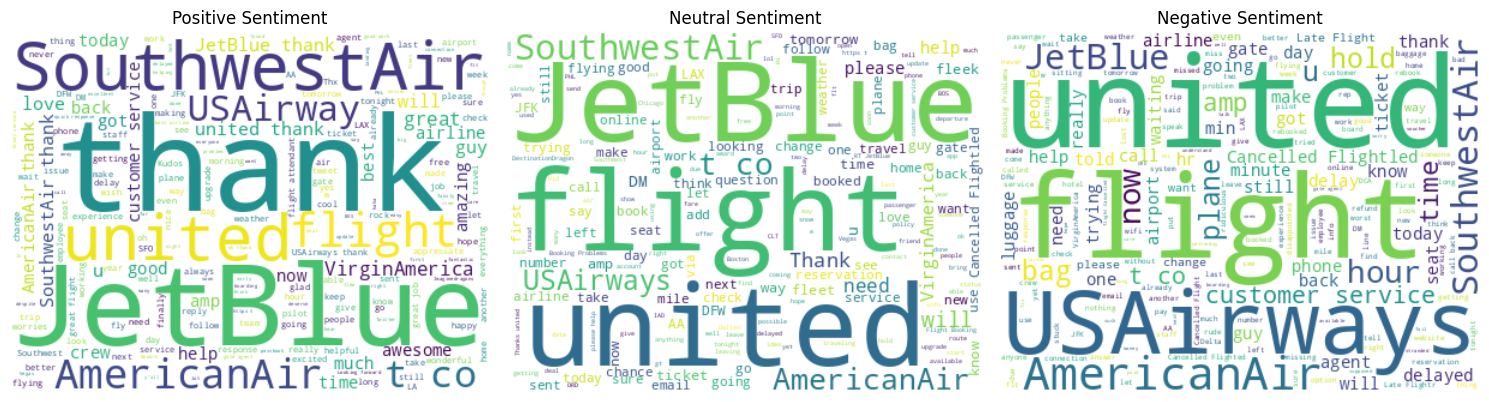

In [8]:
# Install wordcloud
!pip install wordcloud -q

from wordcloud import WordCloud
import matplotlib.pyplot as plt

# ==============================
#  Generate Word Clouds
# ==============================

# Separate text by sentiment
positive_text = " ".join(df[df['airline_sentiment'] == 'positive']['text'])
neutral_text  = " ".join(df[df['airline_sentiment'] == 'neutral']['text'])
negative_text = " ".join(df[df['airline_sentiment'] == 'negative']['text'])

# Create WordCloud objects
wc_positive = WordCloud(width=400, height=300, background_color='white').generate(positive_text)
wc_neutral  = WordCloud(width=400, height=300, background_color='white').generate(neutral_text)
wc_negative = WordCloud(width=400, height=300, background_color='white').generate(negative_text)

# Plot side by side
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(wc_positive, interpolation='bilinear')
plt.title("Positive Sentiment")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(wc_neutral, interpolation='bilinear')
plt.title("Neutral Sentiment")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(wc_negative, interpolation='bilinear')
plt.title("Negative Sentiment")
plt.axis('off')

plt.tight_layout()
plt.show()


**Top 3 negative words & interpretation:**

> The most prominent words in the negative sentiment word cloud are “flight”, “cancelled”, and “delayed”.
These words are highly meaningful as they directly reflect common customer complaints. Terms like “cancelled” and “delayed” clearly indicate negative experiences with airline services, while “flight” provides context and appears frequently in complaint-related tweets. This shows that most negative sentiments are associated with disruptions in flight schedules and poor service experiences.

---
# 🧹 Section 3: Text Preprocessing
*(20 marks)*

### ❓ Question 3.1 — Text Cleaning Function

Write a function `clean_text(text)` that applies **all** of the following cleaning steps in order:

1. Convert to **lowercase**
2. Remove **URLs** (http/https links)
3. Remove **Twitter @mentions**
4. Remove **hashtag symbols** (keep the word, remove the `#`)
5. Remove **punctuation and special characters**
6. Remove **numbers**
7. Remove **extra whitespace** (strip leading/trailing spaces)
8. Remove **stopwords** using NLTK's English stopword list

Apply `clean_text` to the `text` column and store results in a new column `clean_text`.  
Show 5 sample rows comparing original `text` and `clean_text`.

In [9]:
import nltk
nltk.download('stopwords', quiet=True)

import re
import string
from nltk.corpus import stopwords

# Load stopwords
stop_words = set(stopwords.words('english'))

# YOUR CODE HERE
def clean_text(text):
    """
    Clean a raw tweet string.
    Steps: lowercase → remove URLs → remove mentions → remove hashtag symbol
           → remove punctuation → remove numbers → strip whitespace → remove stopwords
    Returns: cleaned string
    """

    # 1. Lowercase
    text = text.lower()

    # 2. Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # 3. Remove @mentions
    text = re.sub(r'@\w+', '', text)

    # 4. Remove hashtag symbol (# but keep word)
    text = re.sub(r'#', '', text)

    # 5. Remove punctuation & special characters
    text = re.sub(r'[^\w\s]', '', text)

    # 6. Remove numbers
    text = re.sub(r'\d+', '', text)

    # 7. Remove extra whitespace
    text = text.strip()
    text = re.sub(r'\s+', ' ', text)

    # 8. Remove stopwords
    words = text.split()
    words = [word for word in words if word not in stop_words]

    return " ".join(words)


# ==============================
# Apply and display
# ==============================

df['clean_text'] = df['text'].apply(clean_text)

# Show comparison
df[['text', 'clean_text']].head()

,text,clean_text
0,@VirginAmerica What @dhepburn said.,said
1,@VirginAmerica plus you've added commercials t...,plus youve added commercials experience tacky
2,@VirginAmerica I didn't today... Must mean I n...,didnt today must mean need take another trip
3,@VirginAmerica it's really aggressive to blast...,really aggressive blast obnoxious entertainmen...
4,@VirginAmerica and it's a really big bad thing...,really big bad thing


### ❓ Question 3.2 — Label Encoding

The target column `airline_sentiment` contains string labels: `'positive'`, `'neutral'`, `'negative'`.

1. Use `sklearn.preprocessing.LabelEncoder` to encode the labels into integers.
2. Store the encoded labels in a column called `label`.
3. Print the mapping of class name → integer for all three classes.
4. How many unique classes are there? Store this in a variable `NUM_CLASSES`.

In [10]:
# YOUR CODE HERE

from sklearn.preprocessing import LabelEncoder

# Initialize encoder
le = LabelEncoder()

# Encode labels
df['label'] = le.fit_transform(df['airline_sentiment'])

# Print mapping
print("Class Mapping:")
for i, class_name in enumerate(le.classes_):
    print(f"{class_name} → {i}")

# Number of unique classes
NUM_CLASSES = len(le.classes_)

print("\nNumber of classes:", NUM_CLASSES)


Class Mapping:
negative → 0
neutral → 1
positive → 2

Number of classes: 3


### ❓ Question 3.3 — Tokenization

Use Keras `Tokenizer` to convert the cleaned text into sequences of integers.

1. Set `MAX_VOCAB = 15000` (vocabulary size).
2. Fit the tokenizer on the `clean_text` column.
3. Convert all texts to sequences.
4. Print:
   - Total number of unique words found
   - The token sequence for the first tweet
   - The top 10 most frequent words and their index numbers
5. Why do we use `oov_token='<OOV>'` in the Tokenizer? Explain briefly.

In [11]:
from tensorflow.keras.preprocessing.text import Tokenizer

# ==============================
# Tokenization
# ==============================

MAX_VOCAB = 15000

# Initialize tokenizer
tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')

# Fit on cleaned text
tokenizer.fit_on_texts(df['clean_text'])

# Convert text to sequences
sequences = tokenizer.texts_to_sequences(df['clean_text'])

# ==============================
#  Outputs
# ==============================

# Total unique words
print("Total unique words:", len(tokenizer.word_index))

# First tweet sequence
print("\nFirst tweet sequence:")
print(sequences[0])

# Top 10 most frequent words
print("\nTop 10 most frequent words:")
word_index = tokenizer.word_index

# Sort by index (frequency rank)
top_10 = list(word_index.items())[:10]

for word, idx in top_10:
    print(f"{word} → {idx}")

Total unique words: 12433

First tweet sequence:
[130]

Top 10 most frequent words:
<OOV> → 1
flight → 2
get → 3
thanks → 4
cancelled → 5
service → 6
help → 7
time → 8
im → 9
customer → 10


**Why use `oov_token='<OOV>'`?**

> The oov_token is used to handle out-of-vocabulary words, i.e., words that were not seen during training.
When the model encounters new or rare words, they are replaced with the <OOV> token instead of being ignored.
This ensures consistent input representation and prevents errors during prediction.

### ❓ Question 3.4 — Padding Sequences

1. Set `MAX_LEN` to the value you chose in Q2.4.
2. Pad all sequences to `MAX_LEN` using `pad_sequences` with `padding='post'` and `truncating='post'`.
3. Print the shape of the padded array.
4. What is the difference between `padding='pre'` and `padding='post'`? Which is generally preferred for RNN-based models and why?

In [12]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# ==============================
# Padding Sequences
# ==============================

# From Q2.4
MAX_LEN = 30

# Pad sequences
X = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')

# Print shape
print("Shape of padded data:", X.shape)

Shape of padded data: (14640, 30)


**Difference between `pre` and `post` padding, and your preference:**

> padding='pre' adds zeros at the beginning of the sequence, while padding='post' adds zeros at the end of the sequence.
For RNN-based models, padding='post' is generally preferred because it allows the model to process the actual words first and pushes the padding to the end. This helps the model learn meaningful patterns more effectively without being influenced by unnecessary zeros at the start.

### ❓ Question 3.5 — Train / Validation / Test Split

Split the padded data into **three sets**:

- **Training set:** 70%
- **Validation set:** 15%
- **Test set:** 15%

Use `stratify=y` to preserve class proportions in each split.  
Print the shape of `X_train`, `X_val`, `X_test`, `y_train`, `y_val`, `y_test`.

In [13]:
# YOUR CODE HERE
from sklearn.model_selection import train_test_split

# Features and labels
y = df['label'].values

# ==============================
# First split (Train 70%, Temp 30%)
# ==============================

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

# ==============================
# Second split (Validation 15%, Test 15%)
# ==============================

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,   # half of 30% → 15% each
    stratify=y_temp,
    random_state=42
)

# ==============================
# Print Shapes
# ==============================

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)
print("y_test shape:", y_test.shape)

X_train shape: (10248, 30)
X_val shape: (2196, 30)
X_test shape: (2196, 30)
y_train shape: (10248,)
y_val shape: (2196,)
y_test shape: (2196,)


---
# 🏗️ Section 4: Model Building
*(30 marks)*

### ❓ Question 4.1 — Define Common Hyperparameters

Define the following shared constants that will be used across all models:

| Variable | Value |
|----------|-------|
| `EMBED_DIM` | 64 |
| `UNITS` | 64 |
| `DROPOUT_RATE` | 0.3 |
| `BATCH_SIZE` | 64 |
| `EPOCHS` | 10 |

Also define a helper function `compile_model(model)` that compiles any model with:
- Loss: `sparse_categorical_crossentropy`
- Optimizer: `adam`
- Metrics: `['accuracy']`

In [14]:
# YOUR CODE HERE
# ==============================
# Common Hyperparameters
# ==============================

EMBED_DIM = 64
UNITS = 64
DROPOUT_RATE = 0.3
BATCH_SIZE = 64
EPOCHS = 10

# ==============================
#  Compile Function
# ==============================

def compile_model(model):
    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )
    return model

### ❓ Question 4.2 — Build a Simple RNN Model

Define a function `build_simple_rnn()` that returns a **compiled** `Sequential` model with the following architecture:

```
Embedding  →  SimpleRNN  →  Dropout  →  Dense(NUM_CLASSES, softmax)
```

Requirements:
- Use `EMBED_DIM`, `UNITS`, `DROPOUT_RATE`, `MAX_VOCAB`, `MAX_LEN` defined earlier.
- The Embedding layer should include `input_length=MAX_LEN`.
- Use `compile_model()` to compile.

Call the function, store it in `rnn_model`, and print its **summary**.

In [17]:
# YOUR CODE HERE

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dropout, Dense

def build_simple_rnn():
    """
    Architecture: Embedding → SimpleRNN → Dropout → Dense(softmax)
    """
    model = Sequential([
        Embedding(input_dim=MAX_VOCAB, output_dim=EMBED_DIM, input_length=MAX_LEN),
        SimpleRNN(UNITS),
        Dropout(DROPOUT_RATE),
        Dense(NUM_CLASSES, activation='softmax')
    ])

    return compile_model(model)


# rnn_model = build_simple_rnn()
# rnn_model.summary()
rnn_model = build_simple_rnn()
rnn_model.build(input_shape=(None, MAX_LEN))
rnn_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 30, 64)         │       960,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 968,451 (3.69 MB)

 Trainable params: 968,451 (3.69 MB)

 Non-trainable params: 0 (0.00 B)

### ❓ Question 4.3 — Build an LSTM Model

Define a function `build_lstm()` that returns a **compiled** `Sequential` model with the following architecture:

```
Embedding  →  LSTM  →  Dropout  →  Dense(NUM_CLASSES, softmax)
```

Requirements:
- Apply **both** `dropout` and `recurrent_dropout` inside the LSTM layer (each = `DROPOUT_RATE`).
- Use the same hyperparameters as Q4.2.

Call the function, store it in `lstm_model`, and print its **summary**.  
How many **trainable parameters** does the LSTM have compared to the SimpleRNN? Explain the difference.

In [18]:
# YOUR CODE HERE

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dropout, Dense

def build_lstm():
    """
    Architecture: Embedding → LSTM → Dropout → Dense(softmax)
    """
    model = Sequential([
        Embedding(input_dim=MAX_VOCAB, output_dim=EMBED_DIM, input_length=MAX_LEN),
        LSTM(UNITS, dropout=DROPOUT_RATE, recurrent_dropout=DROPOUT_RATE),
        Dropout(DROPOUT_RATE),
        Dense(NUM_CLASSES, activation='softmax')
    ])

    return compile_model(model)


# Initialize model
lstm_model = build_lstm()

# Build model (to avoid 0 params issue)
lstm_model.build(input_shape=(None, MAX_LEN))

# Print summary
lstm_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 30, 64)         │       960,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 993,219 (3.79 MB)

 Trainable params: 993,219 (3.79 MB)

 Non-trainable params: 0 (0.00 B)

**Parameter count comparison (RNN vs LSTM) and explanation:**

> The Simple RNN model has 968,451 parameters, while the LSTM model has 993,219 parameters, which is slightly higher.
The LSTM has more parameters because it includes multiple gates (input, forget, and output gates along with cell state), each having separate weight matrices. In contrast, the Simple RNN has only a single hidden state update with fewer parameters.
Although the difference here is not extremely large, the LSTM’s additional parameters allow it to better capture long-term dependencies in text, making it more effective for sequence modeling tasks.

### ❓ Question 4.4 — Build a GRU Model

Define a function `build_gru()` that returns a **compiled** `Sequential` model with the following architecture:

```
Embedding  →  GRU  →  Dropout  →  Dense(NUM_CLASSES, softmax)
```

Requirements:
- Apply `dropout` and `recurrent_dropout` inside the GRU layer.
- Use the same hyperparameters as before.

Call the function, store it in `gru_model`, and print its **summary**.  
Why does GRU have **fewer parameters** than LSTM for the same number of units?

In [19]:
# YOUR CODE HERE

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dropout, Dense

def build_gru():
    """
    Architecture: Embedding → GRU → Dropout → Dense(softmax)
    """
    model = Sequential([
        Embedding(input_dim=MAX_VOCAB, output_dim=EMBED_DIM, input_length=MAX_LEN),
        GRU(UNITS, dropout=DROPOUT_RATE, recurrent_dropout=DROPOUT_RATE),
        Dropout(DROPOUT_RATE),
        Dense(NUM_CLASSES, activation='softmax')
    ])

    return compile_model(model)


# Initialize model
gru_model = build_gru()

# Build model (avoid 0 params issue)
gru_model.build(input_shape=(None, MAX_LEN))

# Print summary
gru_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 30, 64)         │       960,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 985,155 (3.76 MB)

 Trainable params: 985,155 (3.76 MB)

 Non-trainable params: 0 (0.00 B)

**Why does GRU have fewer parameters than LSTM?**

> A GRU has fewer parameters because it uses only two gates (update gate and reset gate), whereas an LSTM uses three gates (input, forget, and output) along with a separate cell state.
Since GRU has a simpler structure with fewer weight matrices, it requires fewer parameters for the same number of units.
This makes GRU computationally more efficient while still capturing important sequence dependencies.


### ❓ Question 4.5 — Build a Stacked Bidirectional LSTM `[10 marks]`

Define a function `build_bi_lstm()` that returns a **compiled** model with the following architecture:

```
Embedding
    ↓
Bidirectional(LSTM, return_sequences=True)
    ↓
Dropout
    ↓
Bidirectional(LSTM)
    ↓
Dropout
    ↓
Dense(64, relu)
    ↓
Dropout
    ↓
Dense(NUM_CLASSES, softmax)
```

After building:
1. Print the model summary.
2. Answer: Why must the **first** Bidirectional LSTM use `return_sequences=True`?
3. Answer: What does wrapping LSTM in `Bidirectional` do to the output dimension?

In [20]:
# YOUR CODE HERE

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dropout, Dense, Bidirectional

def build_bi_lstm():
    """
    Architecture:
    Embedding → BiLSTM(return_sequences=True) → Dropout →
    BiLSTM → Dropout → Dense → Dropout → Output
    """
    model = Sequential([
        Embedding(input_dim=MAX_VOCAB, output_dim=EMBED_DIM, input_length=MAX_LEN),

        Bidirectional(LSTM(UNITS, return_sequences=True,
                           dropout=DROPOUT_RATE,
                           recurrent_dropout=DROPOUT_RATE)),
        Dropout(DROPOUT_RATE),

        Bidirectional(LSTM(UNITS,
                           dropout=DROPOUT_RATE,
                           recurrent_dropout=DROPOUT_RATE)),
        Dropout(DROPOUT_RATE),

        Dense(64, activation='relu'),
        Dropout(DROPOUT_RATE),

        Dense(NUM_CLASSES, activation='softmax')
    ])

    return compile_model(model)


# Initialize model
bi_lstm_model = build_bi_lstm()

# Build model (avoid 0 params issue)
bi_lstm_model.build(input_shape=(None, MAX_LEN))

# Print summary
bi_lstm_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 30, 64)         │       960,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 30, 128)        │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,133,315 (4.32 MB)

 Trainable params: 1,133,315 (4.32 MB)

 Non-trainable params: 0 (0.00 B)

**Answer — `return_sequences=True` requirement:**

> The first Bidirectional LSTM must use return_sequences=True because it is followed by another LSTM layer. This ensures that the full sequence of outputs (one output per time step) is passed to the next layer. Without it, only the final time step output would be returned, and the second LSTM would not receive the complete sequence information.

**Answer — Effect on output dimension:**

> Wrapping an LSTM in a Bidirectional layer processes the input sequence in both forward and backward directions. The outputs from both directions are concatenated, which effectively doubles the output dimension. For example, if the LSTM has 64 units, the Bidirectional output will have 128 features.

---
# 🚀 Section 5: Training & Evaluation
*(20 marks)*

### ❓ Question 5.1 — Add Callbacks `

Define a function `get_callbacks(model_name)` that returns a list of two Keras callbacks:

1. **`EarlyStopping`**: monitor `val_loss`, patience = 3, restore best weights.
2. **`ModelCheckpoint`**: save the best model to `f"{model_name}_best.keras"`, monitor `val_accuracy`.

Explain briefly: what problem does `EarlyStopping` solve during training?

In [21]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# ==============================
#  Callbacks Function
# ==============================

def get_callbacks(model_name):

    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    )

    model_checkpoint = ModelCheckpoint(
        filepath=f"{model_name}_best.keras",
        monitor='val_accuracy',
        save_best_only=True
    )

    return [early_stopping, model_checkpoint]

**What problem does `EarlyStopping` solve?**

> EarlyStopping prevents overfitting during training. It monitors the validation loss and stops training when the model stops improving after a certain number of epochs (patience). This avoids unnecessary training, reduces computation time, and ensures the model retains the best-performing weights.

### ❓ Question 5.2 — Train All Four Models

Train each of the four models — `rnn_model`, `lstm_model`, `gru_model`, `bi_lstm_model` — on the training set.

- Use `X_train`, `y_train` for training and `(X_val, y_val)` for validation.
- Use `EPOCHS`, `BATCH_SIZE`, and the callbacks from Q5.1.
- Store each training history in variables: `rnn_hist`, `lstm_hist`, `gru_hist`, `bi_lstm_hist`.

In [22]:
# ==============================
# 📌 Train All Models
# ==============================

# RNN
rnn_hist = rnn_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks("rnn"),
    verbose=1
)

# LSTM
lstm_hist = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks("lstm"),
    verbose=1
)

# GRU
gru_hist = gru_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks("gru"),
    verbose=1
)

# BiLSTM
bi_lstm_hist = bi_lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks("bi_lstm"),
    verbose=1
)

Epoch 1/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.6756 - loss: 0.7891 - val_accuracy: 0.6749 - val_loss: 0.7395
Epoch 2/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.8124 - loss: 0.4950 - val_accuracy: 0.7077 - val_loss: 0.7088
Epoch 3/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.8987 - loss: 0.2994 - val_accuracy: 0.6521 - val_loss: 0.9321
Epoch 4/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.9334 - loss: 0.2098 - val_accuracy: 0.6607 - val_loss: 1.0024
Epoch 5/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9444 - loss: 0.1717 - val_accuracy: 0.7254 - val_loss: 0.9526
Epoch 1/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 15s 67ms/step - accuracy: 0.6227 - loss: 0.9304 - val_accuracy: 0.6266 - val_loss: 0.9042
Epoch 2/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 10s 64ms/step - accuracy: 0.6922 - loss: 0.7187 - val_accuracy: 0.7372 - val_loss: 0.6368
Epoch 3/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 11s 67ms/step - accuracy: 0.7860 - loss: 0.5460 - val_a

### ❓ Question 5.3 — Plot Training Curves

Create a figure with **2 rows × 4 columns** of subplots (8 plots total).

- **Row 1:** Training vs. Validation **Accuracy** for each of the 4 models.
- **Row 2:** Training vs. Validation **Loss** for each of the 4 models.

Requirements:
- Use a legend on every plot.
- Add clear titles, axis labels.
- Use `plt.tight_layout()`.
- Identify and comment on any model that shows **overfitting**.

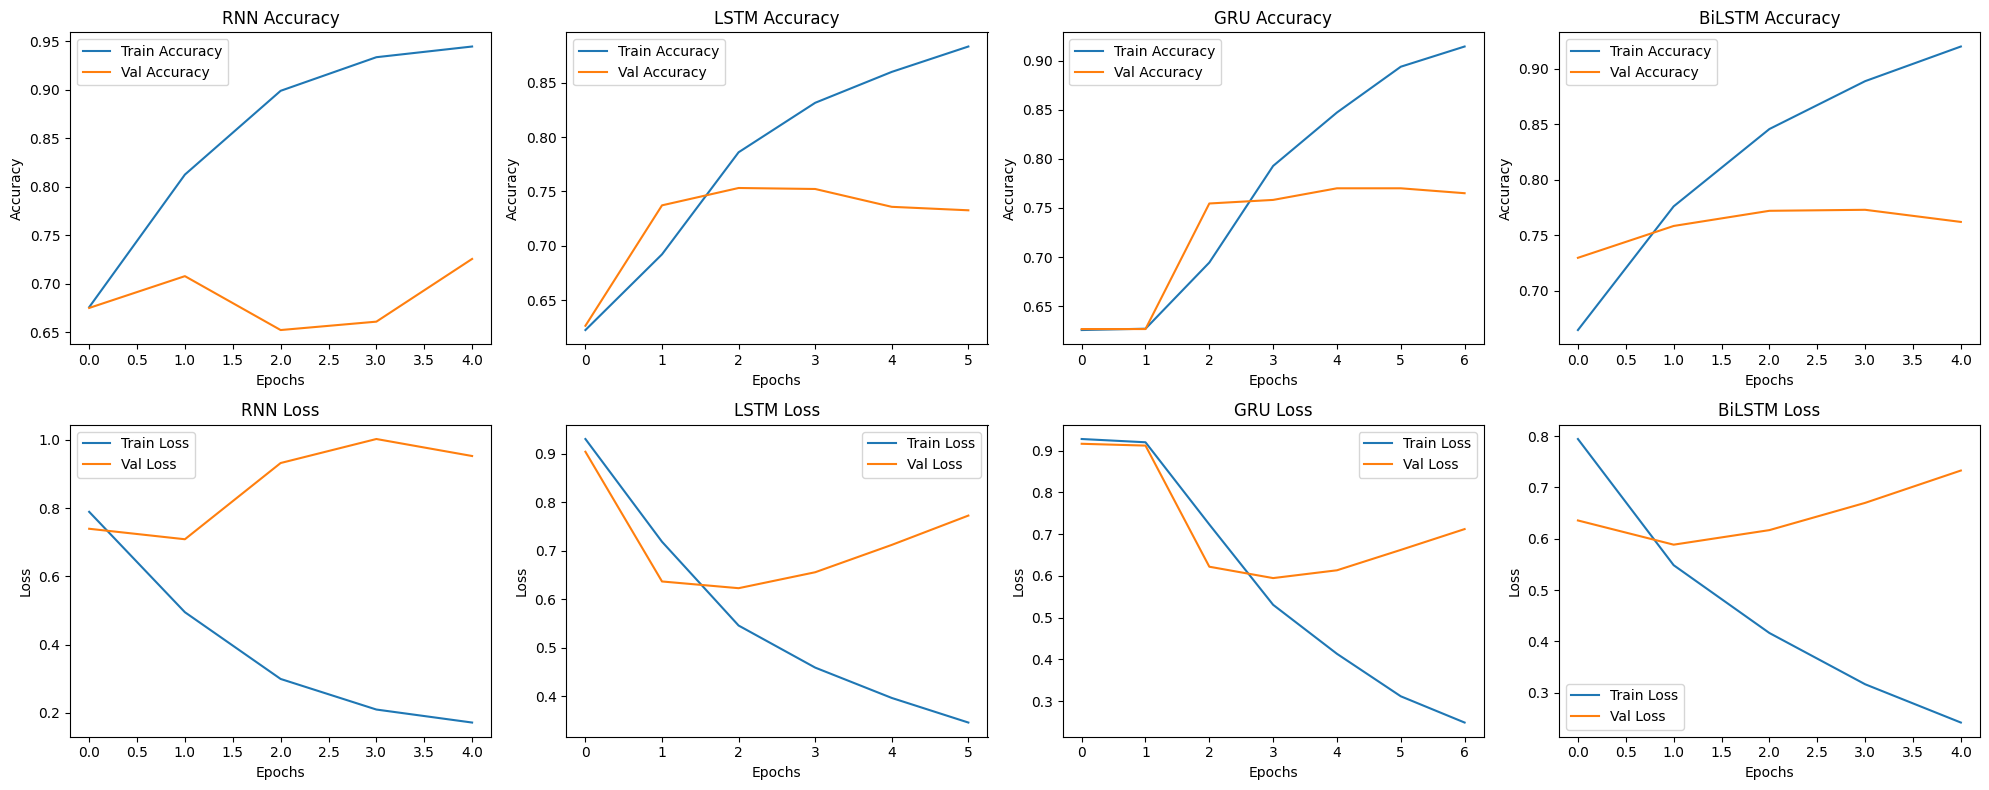

In [23]:
import matplotlib.pyplot as plt

# ==============================
#  Plot Training Curves
# ==============================

fig, axes = plt.subplots(2, 4, figsize=(20, 8))

models = [
    ("RNN", rnn_hist),
    ("LSTM", lstm_hist),
    ("GRU", gru_hist),
    ("BiLSTM", bi_lstm_hist)
]

# Row 1 → Accuracy
for i, (name, hist) in enumerate(models):
    axes[0, i].plot(hist.history['accuracy'], label='Train Accuracy')
    axes[0, i].plot(hist.history['val_accuracy'], label='Val Accuracy')
    axes[0, i].set_title(f"{name} Accuracy")
    axes[0, i].set_xlabel("Epochs")
    axes[0, i].set_ylabel("Accuracy")
    axes[0, i].legend()

# Row 2 → Loss
for i, (name, hist) in enumerate(models):
    axes[1, i].plot(hist.history['loss'], label='Train Loss')
    axes[1, i].plot(hist.history['val_loss'], label='Val Loss')
    axes[1, i].set_title(f"{name} Loss")
    axes[1, i].set_xlabel("Epochs")
    axes[1, i].set_ylabel("Loss")
    axes[1, i].legend()

plt.tight_layout()
plt.show()

**Overfitting observation:**

> *Overfitting can be identified when the training accuracy continues to increase while the validation accuracy plateaus or decreases, and the validation loss starts increasing.
Among the models, the Simple RNN is more likely to show overfitting due to its limited ability to generalize, while deeper models like BiLSTM may also overfit if not properly regularized.
Models like GRU and LSTM generally show better generalization, but slight overfitting may still occur depending on training duration.*

### ❓ Question 5.4 — Evaluate on Test Set `

Evaluate **all four models** on `X_test`, `y_test`. For each model:

1. Print **test loss** and **test accuracy**.
2. Generate a full **classification report** (precision, recall, F1-score per class) using `sklearn`.
3. Store test accuracies in a dictionary `test_results` keyed by model name.

In [24]:
from sklearn.metrics import classification_report
import numpy as np

# ==============================
#  Evaluation Function
# ==============================

def evaluate_model(model, model_name):
    print(f"\n===== {model_name} =====")

    # 1. Evaluate loss & accuracy
    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"Test Loss: {loss:.4f}")
    print(f"Test Accuracy: {acc:.4f}")

    # 2. Predictions
    y_pred_probs = model.predict(X_test)
    y_pred = np.argmax(y_pred_probs, axis=1)

    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=le.classes_))

    return acc


# ==============================
# Evaluate All Models
# ==============================

test_results = {}

test_results['RNN'] = evaluate_model(rnn_model, "RNN")
test_results['LSTM'] = evaluate_model(lstm_model, "LSTM")
test_results['GRU'] = evaluate_model(gru_model, "GRU")
test_results['BiLSTM'] = evaluate_model(bi_lstm_model, "BiLSTM")

# ==============================
# Print Summary
# ==============================

print("\nTest Accuracies:")
print(test_results)


===== RNN =====
Test Loss: 0.6701
Test Accuracy: 0.7236
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step

Classification Report:
              precision    recall  f1-score   support

    negative       0.85      0.82      0.83      1377
     neutral       0.48      0.61      0.54       465
    positive       0.66      0.50      0.57       354

    accuracy                           0.72      2196
   macro avg       0.66      0.64      0.65      2196
weighted avg       0.74      0.72      0.73      2196


===== LSTM =====
Test Loss: 0.5756
Test Accuracy: 0.7810
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step

Classification Report:
              precision    recall  f1-score   support

    negative       0.86      0.89      0.87      1377
     neutral       0.58      0.58      0.58       465
    positive       0.74      0.62      0.68       354

    accuracy                           0.78      2196
   macro avg       0.72      0.70      0.71      2196
weighted avg       0.78      0.78      0.78      2

### ❓ Question 5.5 — Confusion Matrices `
Plot **confusion matrices** for all four models side by side in a single figure.

- Use `seaborn.heatmap` with `annot=True`, `fmt='d'`, and a suitable colormap.
- Label the axes with the actual class names (positive / neutral / negative).
- Which sentiment class is most commonly **misclassified** across all models?

69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step


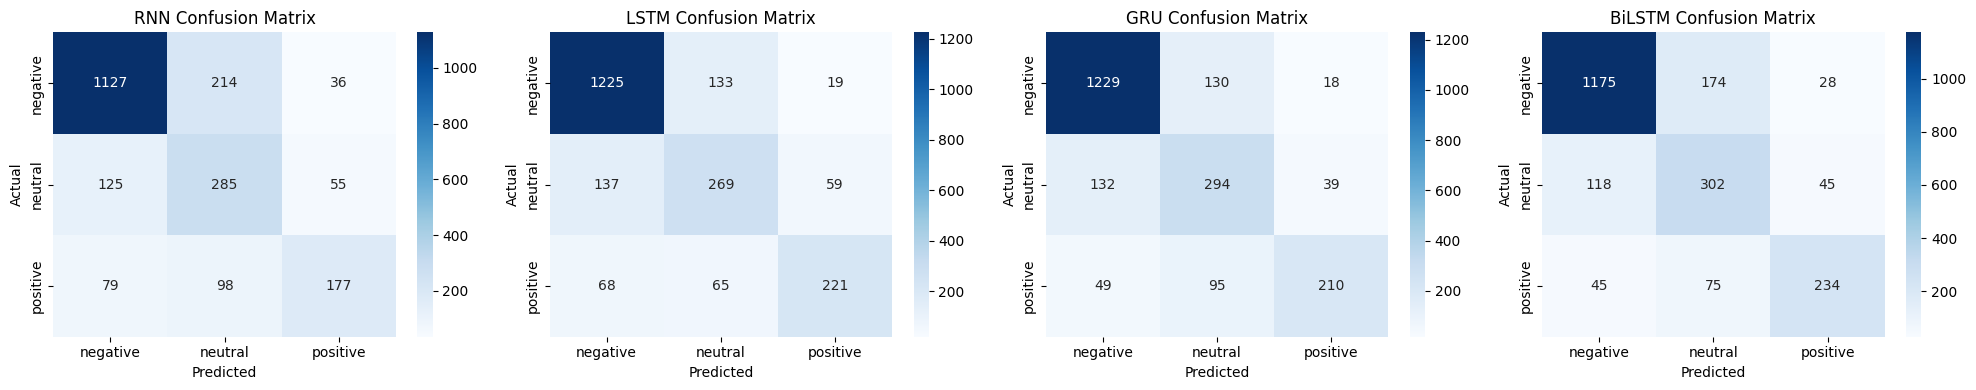

In [25]:
# YOUR CODE HERE
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Class names
class_names = le.classes_

# ==============================
# Function to get predictions
# ==============================

def get_predictions(model):
    y_pred_probs = model.predict(X_test)
    return np.argmax(y_pred_probs, axis=1)

# Get predictions
rnn_pred = get_predictions(rnn_model)
lstm_pred = get_predictions(lstm_model)
gru_pred = get_predictions(gru_model)
bi_lstm_pred = get_predictions(bi_lstm_model)

# Compute confusion matrices
cms = [
    ("RNN", confusion_matrix(y_test, rnn_pred)),
    ("LSTM", confusion_matrix(y_test, lstm_pred)),
    ("GRU", confusion_matrix(y_test, gru_pred)),
    ("BiLSTM", confusion_matrix(y_test, bi_lstm_pred))
]

# ==============================
# Plot
# ==============================

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for i, (name, cm) in enumerate(cms):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names,
                ax=axes[i])

    axes[i].set_title(f"{name} Confusion Matrix")
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

plt.tight_layout()
plt.show()

**Most commonly misclassified class and reasoning:**

> The neutral sentiment class is the most commonly misclassified across all models. From the confusion matrices, a significant number of neutral tweets are incorrectly predicted as either negative or positive. This happens because neutral tweets often contain ambiguous or mixed language without strong emotional cues, making them harder for the models to distinguish. In contrast, negative and positive tweets usually contain clearer sentiment-indicating words, leading to better classification accuracy for those classes.

---
# 🔍 Section 6: Analysis & Inference
*(10 marks)*

### ❓ Question 6.1 — Model Comparison Summary `

Complete the table below based on your results:

| Model  | Test Accuracy | Macro F1-Score | Total Parameters | Epochs Run |
| ------ | ------------- | -------------- | ---------------- | ---------- |
| RNN    | 0.7236        | 0.65           | 968,451          | 5          |
| LSTM   | 0.7810        | 0.71           | 993,219          | 6          |
| GRU    | **0.7892**    | **0.72**       | 985,155          | 7          |
| BiLSTM | 0.7791        | 0.72           | **1,133,315**    | 5          |


Which model gave the **best accuracy-to-parameter ratio**? Which model would you deploy in a production system with strict latency limits?

**Fill in the table above. Then answer:**

- Best accuracy-to-parameter ratio: GRU
Reason:
Highest accuracy: 0.7892
Moderate parameter count (~985K)
Better efficiency than LSTM and BiLSTM
Slightly better performance than BiLSTM despite lower cost

- Production choice (latency-constrained):
>GRU

Justification:
Faster inference than LSTM and BiLSTM
Lower computational overhead than BiLSTM (bidirectional doubling effect)
Best accuracy among all models
Stable training curve without heavy overfitting like RNN

### ❓ Question 6.2 — Live Prediction Function

Write a function `predict_sentiment(text, model, label_encoder)` that:

1. Cleans the input text using your `clean_text()` function.
2. Tokenizes and pads it to `MAX_LEN`.
3. Predicts the sentiment class using the given model.
4. Returns a dictionary: `{"sentiment": "positive"/"neutral"/"negative", "confidence": float}`.

Test your function with the **best-performing model** on these 5 tweets:

```python
test_tweets = [
    "@SouthwestAir Thank you so much for the amazing service today! Best flight ever!",
    "@united my bag was lost AGAIN. Third time this year. Absolutely unacceptable.",
    "@AmericanAir Flight delayed by 2 hours. No explanation given.",
    "@Delta Just landed. Flight was on time, nothing special to report.",
    "@JetBlue the crew was incredibly kind and the seats were comfortable!"
]
```

Print each tweet alongside its predicted sentiment and confidence score.

In [26]:
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

def predict_sentiment(text, model, label_encoder):

    # 1. Clean text
    cleaned = clean_text(text)

    # 2. Tokenize (assumes you already have tokenizer fitted)
    seq = tokenizer.texts_to_sequences([cleaned])

    # 3. Pad sequence
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')

    # 4. Predict
    probs = model.predict(padded, verbose=0)[0]

    # 5. Get class + confidence
    idx = np.argmax(probs)
    sentiment = label_encoder.inverse_transform([idx])[0]
    confidence = float(np.max(probs))

    return {
        "sentiment": sentiment,
        "confidence": confidence
    }

In [27]:
test_tweets = [
    "@SouthwestAir Thank you so much for the amazing service today! Best flight ever!",
    "@united my bag was lost AGAIN. Third time this year. Absolutely unacceptable.",
    "@AmericanAir Flight delayed by 2 hours. No explanation given.",
    "@Delta Just landed. Flight was on time, nothing special to report.",
    "@JetBlue the crew was incredibly kind and the seats were comfortable!"
]

for tweet in test_tweets:
    result = predict_sentiment(tweet, gru_model, le)

    print("\nTweet:", tweet)
    print("Predicted Sentiment:", result["sentiment"])
    print("Confidence:", round(result["confidence"], 4))


Tweet: @SouthwestAir Thank you so much for the amazing service today! Best flight ever!
Predicted Sentiment: positive
Confidence: 0.9316

Tweet: @united my bag was lost AGAIN. Third time this year. Absolutely unacceptable.
Predicted Sentiment: negative
Confidence: 0.9895

Tweet: @AmericanAir Flight delayed by 2 hours. No explanation given.
Predicted Sentiment: negative
Confidence: 0.9882

Tweet: @Delta Just landed. Flight was on time, nothing special to report.
Predicted Sentiment: negative
Confidence: 0.9414

Tweet: @JetBlue the crew was incredibly kind and the seats were comfortable!
Predicted Sentiment: neutral
Confidence: 0.6026


### ❓ Question 6.3 — Reflection Questions `

Answer the following in **2–3 sentences each**:

1. The dataset is imbalanced (dominated by negative tweets). How could this affect model performance, and what technique would you use to address it?

2. How would using **pre-trained word embeddings** (e.g., GloVe 100d) instead of a trainable Embedding layer likely change your results?

3. What is one advantage **Transformers** (e.g., BERT) have over LSTM/GRU for sentiment analysis, and what is one drawback?

**1. Class imbalance effect and remedy:**

> The dataset imbalance (more negative tweets) can cause the model to become biased toward predicting the negative class more frequently, reducing its ability to correctly identify neutral and positive sentiments. This leads to poor recall and unfair performance across classes even if overall accuracy looks high. To handle this, techniques like class weighting, oversampling minority classes, or using focal loss can be applied to balance the learning process.

**2. Pre-trained embeddings vs trainable embeddings:**

> Using pre-trained embeddings like GloVe can improve model performance because they already capture semantic relationships between words learned from large external corpora. This helps the model generalize better, especially on small or noisy datasets such as tweets. In contrast, trainable embeddings learn word representations only from the training data, which may result in weaker semantic understanding.

**3. Transformer advantage and drawback vs LSTM/GRU:**

> Transformers such as BERT have the advantage of capturing long-range dependencies in text using self-attention, making them more effective for understanding context compared to LSTM/GRU models. However, a major drawback is their high computational cost, requiring significantly more memory and processing time for training and inference. This makes them less suitable for lightweight or real-time systems compared to GRU or LSTM.

---
# 🌟 Bonus Question — Hyperparameter Tuning `

Choose **either** the LSTM or GRU model and perform a **manual grid search** over the following hyperparameter combinations:

```python
embed_dims   = [32, 64, 128]
units_list   = [32, 64, 128]
dropout_list = [0.2, 0.3, 0.5]
```

Requirements:
1. Train each combination for **5 epochs** (no early stopping for speed).
2. Record `val_accuracy` for each combination.
3. Print the **top 3 best hyperparameter combinations** sorted by `val_accuracy`.
4. Plot a **heatmap** of `val_accuracy` across `embed_dim` vs `units` (fix dropout at 0.3).
5. Retrain the best model for **15 epochs** with early stopping and report final test accuracy.

In [30]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dropout, Dense

def build_gru_model(embed_dim, units, dropout):
    model = Sequential([
        Embedding(input_dim=MAX_VOCAB,
                  output_dim=embed_dim,
                  input_length=MAX_LEN),

        GRU(units,
            dropout=dropout,
            recurrent_dropout=dropout),

        Dropout(dropout),
        Dense(NUM_CLASSES, activation='softmax')
    ])

    return compile_model(model)

In [ ]:
df = pd.DataFrame(results)

top3 = df.sort_values(by="val_accuracy", ascending=False).head(3)

print("\nTop 3 Configurations:")
print(top3[["embed_dim", "units", "dropout", "val_accuracy"]])i